<a href="https://colab.research.google.com/github/iaportnov/gp4_statistics_huistics/blob/main/gp4_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Часть 1.

In [3]:
!wget https://raw.githubusercontent.com/iaportnov/gp4_statistics_huistics/refs/heads/main/data_ab.csv

--2026-05-15 10:10:24--  https://raw.githubusercontent.com/iaportnov/gp4_statistics_huistics/refs/heads/main/data_ab.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15901933 (15M) [text/plain]
Saving to: ‘data_ab.csv’

data_ab.csv         100%[===================>]  15.17M  --.-KB/s    in 0.1s    

2026-05-15 10:10:25 (142 MB/s) - ‘data_ab.csv’ saved [15901933/15901933]



Датасет состоит из пяти столбцов:

* `user_id` — уникальный идентификатор пользователя;

* `timestamp` — время посещения пользователем страницы;

* `group` — группа эксперимента, к которой был случайно отнесён пользователь:

  *   `control` — контрольная группа,
  *   `treatment` — экспериментальная группа;

* `landing_page` — версия лендинга, которую увидел пользователь:

  *   `old_page` — старая версия страницы,
  *   `new_page` — новая версия страницы;

* `converted` — бинарный признак, показывающий, совершил ли пользователь целевое действие (целевым действием является регистрация на курс).

По замыслу A/B-теста контрольной группе (`control`) должна была показываться старая версия лендинга — `old_page`; экспериментальной группе (`treatment`) должна была показываться новая версия лендинга — `new_page`.

Вам следует:
- понять структуру данных, провести EDA и выбрать метрику, с которой будете работать;
- проверить корректность проведения тестирования (посмотреть на однородность групп; задуматься об A/A-тесте; не забыть, что в нашем распоряжении есть еще и временные метки);
- сформулировать нулевую и альтернативную гипотезы на основании выбранной метрики;
- выбрать и обосновать статистический тест;
- решить, нужно ли устаналивать значения каких-либо параметров до начала анализа тестирования;
- оценить разницу в результатах и сделать выводы о практической значимости эксперимента;
- провести дополнительный анализ при необходимости (например, с помощью [bootstrap](https://habr.com/ru/companies/X5Tech/articles/679842/)  или через анализ чувствительности);
- сформулировать рекомендации и бизнес-инсайты по результатам эксперимента.

**Важно**: это лишь возможные шаги для вашего исследования, и воспринимать их следует как подсказки. Ваша центральная задача в любом случае представлена в общем виде — осуществить качественный и полный анализ результатов проведенного A/B-тестирования.



In [128]:
df = pd.read_csv('data_ab.csv')

In [129]:
df

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,0
294474,945152,2025-01-12 00:51:57.078372,control,old_page,0
294475,734608,2025-01-22 11:45:03.439544,control,old_page,0
294476,697314,2025-01-15 01:20:28.957438,control,old_page,0


Всего у нас 294478 записей

In [130]:
df['group'].value_counts()

,count
group,
treatment,147276
control,147202


Изначально у нас 147202 пользователя в контрольной группе и 147276 пользователей в тестовой.

In [131]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [132]:
df['date'] = df['timestamp'].dt.strftime('%Y-%m-%d')
del df['timestamp']

In [133]:
df.date.value_counts().sort_index()

,count
date,
2025-01-02,5783
2025-01-03,13394
2025-01-04,13284
2025-01-05,13124
2025-01-06,13528
2025-01-07,13381
2025-01-08,13564
2025-01-09,13439
2025-01-10,13523


Наш эксперимент шел 23 дня, при этом первый день (2025-01-02) и последний день (2025-01-24) имеют меньше записей, скорее всего тест запустили и закончили в середине соответствующих дней, поэтому в эти даты не получилось набрать соразмерную с другими днями выборку.

<Axes: xlabel='date'>

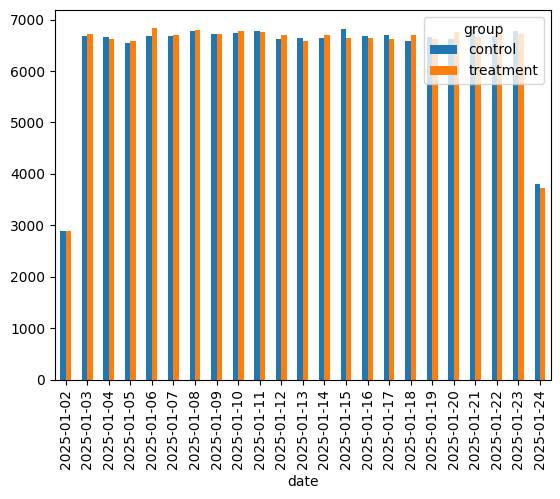

In [134]:
df.groupby(['date','group'])['user_id'].count().unstack().plot(kind='bar')

Тестовая и контрольная выборка распределена по дням почти одинаково.

## Чистим данные от дубликатов и несостыковок

In [135]:
df['user_id'].value_counts()

,count
user_id,
752737,2
781280,2
767913,2
886060,2
731779,2
...,...
653383,1
732573,1
867433,1


Есть пользователи, которые попали в тест дважды, так не должно быть

In [136]:
df.groupby('user_id').filter(lambda x: len(x)>1).sort_values('user_id')

,user_id,group,landing_page,converted,date
213114,630052,treatment,old_page,1,2025-01-07
230259,630052,treatment,new_page,0,2025-01-17
251762,630126,treatment,new_page,0,2025-01-19
22513,630126,treatment,old_page,0,2025-01-14
11792,630137,control,new_page,0,2025-01-22
...,...,...,...,...,...
99479,945703,control,old_page,0,2025-01-18
186960,945797,control,old_page,0,2025-01-13
40370,945797,control,new_page,1,2025-01-11
165143,945971,control,old_page,0,2025-01-16


Интересно, некоторые пользователи видели несколько версий лэндинга, хотя принадлежат к одной группе (control или treatment). Так не должно быть, так как пользователь может действовать иначе заходе на старую страницу, после того как до этого он был на новой, например он такой подумал:

> хмммм, бля, я тут кнопку жмал, а кнопки теперь нет, хуйня не буду ничего искать

Таких пользователей нужно либо удалить, либо оставить их первое взаимодействие.

Тех пользователей, кто относится к какой-то из групп, при этом первой увидел сайт для другой группы следует выкинуть из выборки.


In [137]:
df[df['landing_page']=='new_page'].groupby('user_id').filter(lambda x: len(x)>1).sort_values('user_id')

,user_id,group,landing_page,converted,date
114320,630887,treatment,new_page,0,2025-01-22
28177,630887,control,new_page,0,2025-01-07
39018,631838,control,new_page,0,2025-01-21
145226,631838,treatment,new_page,0,2025-01-09
121799,632464,treatment,new_page,0,2025-01-06
...,...,...,...,...,...
63432,945125,treatment,new_page,0,2025-01-14
183169,945387,treatment,new_page,0,2025-01-03
275158,945387,control,new_page,0,2025-01-20
243428,945627,treatment,new_page,1,2025-01-17


Хах, оказывается есть такие пользователи, которые попали и в тест, и в контроль, оставим их группу из первой интеракции, если вид сайта совпадает с нужной для группы.

In [138]:
df = df.sort_values(['user_id','date']).drop_duplicates('user_id', keep='first')

In [139]:
df = df[((df['group']=='control') & (df['landing_page']=='old_page')) | ((df['group']=='treatment') & (df['landing_page']=='new_page'))]

In [140]:
df.groupby('user_id').filter(lambda x: len(x)>1).sort_values('user_id')

,user_id,group,landing_page,converted,date


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288629 entries, 63114 to 237031
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       288629 non-null  int64 
 1   group         288629 non-null  object
 2   landing_page  288629 non-null  object
 3   converted     288629 non-null  int64 
 4   date          288629 non-null  object
dtypes: int64(2), object(3)
memory usage: 13.2+ MB


ВСЕ! Теперь для каждого пользователя хранится только первая интеракция и у всех группа соответствует версии сайта.

Убрали около 6к записей.

## Смотрим на однородность выборок

Круто будет посмотреть на то, что пользователи в случайных выборках по дням ведут себя одинаково

In [147]:
from statsmodels.stats.proportion import proportions_ztest

In [218]:
def splitter(sample, n=1000, random_state = 52):
  if len(sample)>=2*n:
    sample = sample.sample(n = 2*n, random_state = random_state)
    sample1, sample2 = sample.iloc[:n], sample.iloc[n:]
    return sample1, sample2

In [247]:
def check_ci(sample, n=1000, col_name='converted', random_state = 67):
  s1,s2 = splitter(sample, n=n, random_state = random_state)
  m1, m2 = s1[s1[col_name]==1], s2[s2[col_name]==1]
  return proportions_ztest([len(m1),len(m2)],[len(s1),len(s2)])[1]

In [250]:
check = {}
for group in ['control', 'treatment']:
  for date in df['date'].sort_values().unique():
    check[f'{group} {date}'] = 0
    if (pval:=check_ci(df[(df['date']==date)&(df['group']==group)])) > 0.00:
        check[f'{group} {date}'] = pval

In [251]:
check

{'control 2025-01-02': np.float64(0.15776535255948132),
 'control 2025-01-03': np.float64(0.7860967357383207),
 'control 2025-01-04': np.float64(0.276015941823074),
 'control 2025-01-05': np.float64(0.5764181184562502),
 'control 2025-01-06': np.float64(0.2036131682302298),
 'control 2025-01-07': np.float64(0.08284348654999747),
 'control 2025-01-08': np.float64(0.29399929336703623),
 'control 2025-01-09': np.float64(0.5778370961018353),
 'control 2025-01-10': np.float64(0.3948551308004111),
 'control 2025-01-11': np.float64(0.012511413943612583),
 'control 2025-01-12': np.float64(0.7366146241935624),
 'control 2025-01-13': np.float64(0.7800052638076349),
 'control 2025-01-14': np.float64(0.8331423117140763),
 'control 2025-01-15': np.float64(0.5047179446191302),
 'control 2025-01-16': np.float64(0.23953399155214583),
 'control 2025-01-17': np.float64(0.4139372013170276),
 'control 2025-01-18': np.float64(0.4913883287047909),
 'control 2025-01-19': np.float64(0.46233424916965593),
 'co

In [101]:
df['date'].iloc[0]

datetime.date(2025, 1, 19)

In [105]:
df[(df['date']==pd.to_datetime('2025-01-16').date())&(df['group']=='control')]

,user_id,group,landing_page,converted,date
103873,630001,treatment,new_page,1,2025-01-16
187023,630016,treatment,new_page,0,2025-01-16
217037,630043,treatment,new_page,0,2025-01-16
139909,630061,control,old_page,0,2025-01-16
201453,630097,treatment,new_page,1,2025-01-16
...,...,...,...,...,...
150681,945945,control,old_page,0,2025-01-16
42664,945964,treatment,new_page,0,2025-01-16
165143,945971,control,old_page,0,2025-01-16
241062,945998,control,old_page,0,2025-01-16


In [117]:
s1,s2 = splitter(df[(df['date']==pd.to_datetime('2025-01-16').date())&(df['group']=='control')])

In [120]:
get_metric(s1)

0.111

In [121]:
get_metric(s2)

0.133

In [84]:
df

,user_id,group,landing_page,converted,date
63114,630000,treatment,new_page,0,2025-01-19
103873,630001,treatment,new_page,1,2025-01-16
205236,630002,control,old_page,0,2025-01-19
247344,630003,treatment,new_page,0,2025-01-12
242283,630004,treatment,new_page,0,2025-01-18
...,...,...,...,...,...
274312,945994,control,old_page,0,2025-01-03
275777,945996,treatment,new_page,0,2025-01-09
109353,945997,control,old_page,0,2025-01-04
241062,945998,control,old_page,0,2025-01-16


In [254]:
for date in df['date'].sort_values().unique():
  for group in ['control', 'treatment']:
    print(group, date, round(df[(df['date']==date)&(df['group']==group)]['converted'].mean(),4))
  print('---------------------------------')

control 2025-01-02 0.1256
treatment 2025-01-02 0.1199
---------------------------------
control 2025-01-03 0.1137
treatment 2025-01-03 0.1138
---------------------------------
control 2025-01-04 0.122
treatment 2025-01-04 0.1167
---------------------------------
control 2025-01-05 0.1235
treatment 2025-01-05 0.1152
---------------------------------
control 2025-01-06 0.1152
treatment 2025-01-06 0.1231
---------------------------------
control 2025-01-07 0.1209
treatment 2025-01-07 0.1163
---------------------------------
control 2025-01-08 0.1191
treatment 2025-01-08 0.1209
---------------------------------
control 2025-01-09 0.1195
treatment 2025-01-09 0.1185
---------------------------------
control 2025-01-10 0.1131
treatment 2025-01-10 0.1264
---------------------------------
control 2025-01-11 0.1188
treatment 2025-01-11 0.1155
---------------------------------
control 2025-01-12 0.1223
treatment 2025-01-12 0.1219
---------------------------------
control 2025-01-13 0.1171
treatme